# Introduction to Machine Learning -- MC886
# Assignment 2 - Model Selection and Regularization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [11]:
# Please, enter your name and RA number in the lines below:
print("Student 1", "|", "RA1")
print("Student 2", "|", "RA2")
print("Student 3", "|", "RA3")  # You may remove this line if you are only 2 students in the group

Student 1 | RA1
Student 2 | RA2
Student 3 | RA3


---

## Objective

This assignment investigates the effects of overfitting in different data regimes
and test conditions.
The goal is to understand the different results of regularization when data
availability changes, and how they impact the generalization across two different
distributions.

### Guidelines

> Please read these guidelines carefully.

1. Questions can be answered in English or in Portuguese.

2. Use data visualization as a primary tool for understanding the problem. Inspect the training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves only as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for implementation support. The use of AI for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

5. Do not hesitate to reach out to the PED/PAD via Discord.

In [12]:
from numpy.typing import NDArray
import numpy as np
import matplotlib.pylab as plt
import random
import torch

### About the Dataset

This assignment uses the [MNIST](https://web.archive.org/web/20240213122836/http://yann.lecun.com/exdb/mnist/) dataset, a standard benchmark for image classification. It consists of 28×28 grayscale images of handwritten digits (0–9), where each pixel encodes an intensity value in [0, 255].

MNIST is useful here because it is simple enough that a linear model can do well on it, which means the learned weights are directly interpretable as images, where each weight corresponds to the influence of each pixel.

To study robustness and distribution shift, this assignment uses corrupted variants from [MNIST-C](https://github.com/google-research/mnist-c), which applies systematic corruptions to the original images.

The training set consists entirely of corrupted images. The test set contains **two splits**:
- `test_corrupted`: corrupted test images (same distribution as training).
- `test_clean`: the original, uncorrupted MNIST test images.

Performance on `test_corrupted` measures how well the model learned the training task.
Performance on `test_clean` measures how well the model learned digit recognition.

Your job is to train three different models, each one with different number of
available samples:
- Full-data (60000 samples)
- Partial-data (10000 samples)
- Scarce-data (1000 samples)

Finding the best combination of hyper-parameter for each one of them.

In [13]:
# The dataset is available in the classroom assignment.
# Ensure you have downloaded it and placed it alongside this notebook.

# DO NOT change this cell

def subsample_dataset(
    X: NDArray[Any], y: NDArray[Any], n: int
) -> tuple[NDArray[Any], NDArray[Any]]:
    n_samples = len(y)

    idxs = np.random.choice(
        n_samples, size=n, replace=False
    )

    return X[idxs], y[idxs]

X_full = np.load("data/train/train_images.npy")
y_full = np.load("data/train/train_labels.npy")

X_partial, y_partial = subsample_dataset(X_full, y_full, 10_000)
X_scarce, y_scarce = subsample_dataset(X_full, y_full, 1_000)

print(f"Full-data set: {X_full.shape[0]} samples")
print(f"Partial-data set: {X_partial.shape[0]} samples")
print(f"Scarce-data set: {X_scarce.shape[0]} samples")

Full-data set: 60000 samples
Partial-data set: 10000 samples
Scarce-data set: 1000 samples


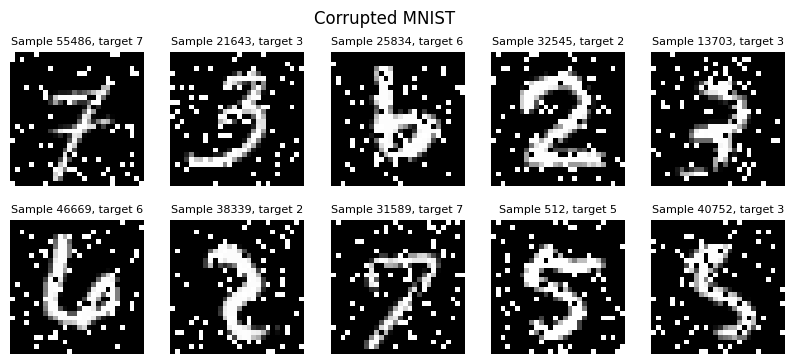

In [14]:
n_cols = 5
n_rows = 2

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))

fig.suptitle("Corrupted MNIST")

for i in range(n_rows):
    for j in range(n_cols):
        ax = axs[i, j]
        idx = random.randint(0, len(X_full)-1)

        ax.set_title(f"Sample {idx}, target {y_full[idx]}", fontsize=8)
        ax.imshow(X_full[idx], cmap='grey')
        ax.set_axis_off()

---

## Part 1. Data Analysis and Preprocessing

### 1.1 Exploring the corruption

**(1.0 point)**

Before any modeling, understand what the corruption actually does to the data.

Is the corruption random per-pixel noise, or is it a structured perturbation?
Explore the **training** dataset, understand the distribution and the effects of the introduced
noise.

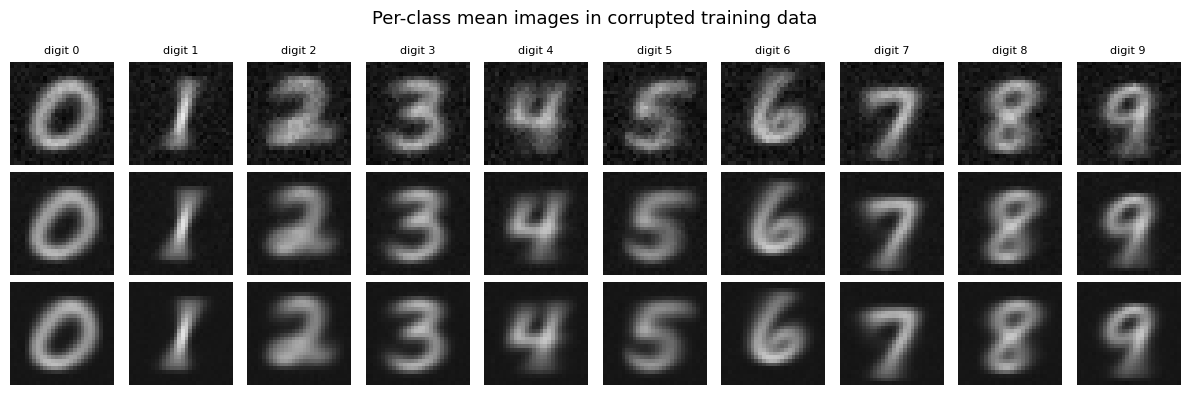

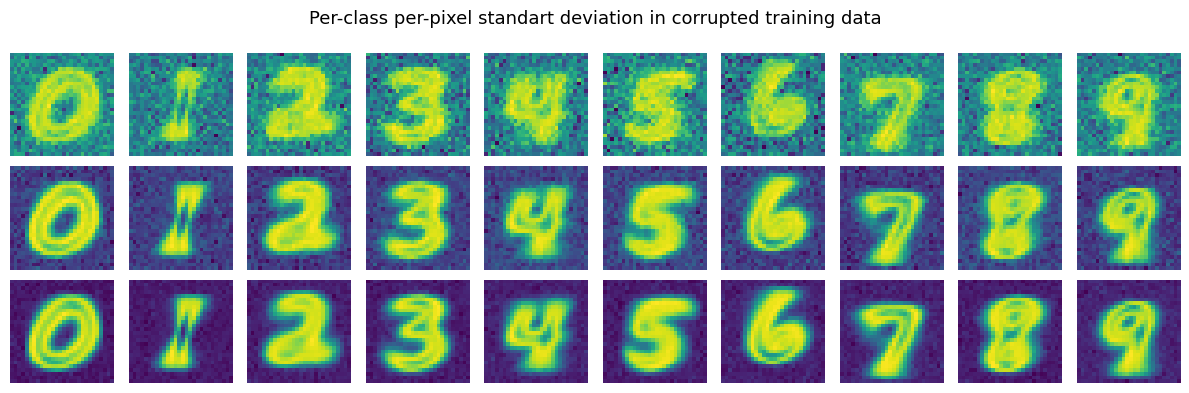

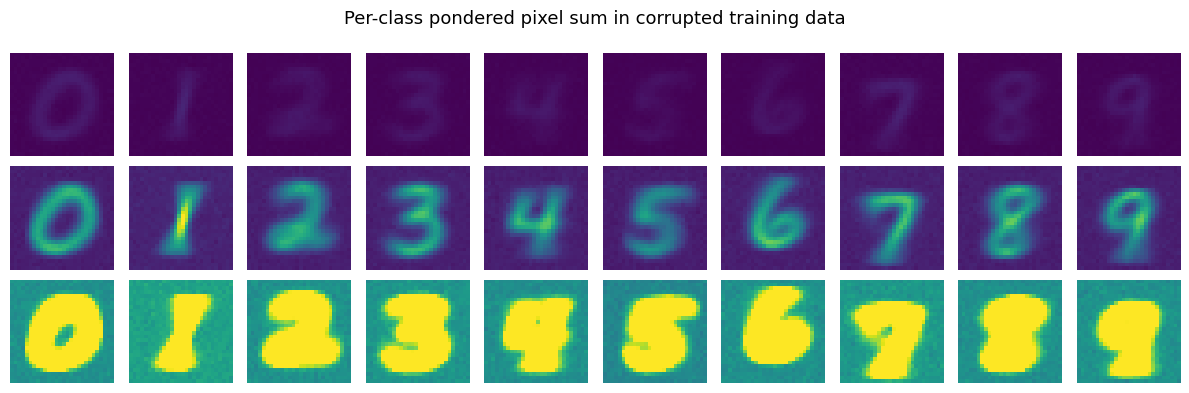

In [15]:
data_regimes = {
    "Scarce": (X_scarce, y_scarce),
    "Partial": (X_partial, y_partial),
    "Full": (X_full, y_full),
}

mean_fig, mean_axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
std_fig, std_axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
sum_fig, sum_axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))

for digit in range(10):
    mean_axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]


    for digit in range(10):
        mask = (y == digit)
        sum_weight = 1e-3

        mean_img = X[mask].mean(axis=0)
        std_img = X[mask].std(axis=0)
        sum_img = (X[mask]*sum_weight).sum(axis=0)

        mean_axs[i, digit].imshow(mean_img, cmap="gray", vmin=0, vmax=255)
        mean_axs[i, digit].axis("off")
        std_axs[i, digit].imshow(std_img, cmap="viridis", vmin=std_img.min(), vmax=std_img.max())
        std_axs[i, digit].axis("off")
        sum_axs[i, digit].imshow(sum_img, cmap="viridis", vmin=0, vmax=255)
        sum_axs[i, digit].axis("off")

    mean_axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)
    std_axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)
    sum_axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)



mean_fig.suptitle("Per-class mean images in corrupted training data", fontsize=13)
mean_fig.tight_layout()

std_fig.suptitle("Per-class per-pixel standart deviation in corrupted training data", fontsize=13)
std_fig.tight_layout()
 
sum_fig.suptitle("Per-class pondered pixel sum in corrupted training data", fontsize=13)
sum_fig.tight_layout()

plt.show()

> **Question 1.1**
>
> Describe the corruption. Is it random and per-sample, or is it systematic and shared across images? Does it vary across digit classes?
>
> Are there data regimes where the corruption can effect more than in others?
> Hypothesize how these different regimes will affect a model trained on them.



A distorção aplicada consiste em flips aleatórios aplicados as imagens do dataset original. Têm-se um forte indicativo de que o ruído adicionado é uniformemente distribuído pela imagem e independe da classe, ou seja, não há uma observação que revele alguma corrupção sistematica dentro de uma mesma classe ou que se diferencie entre classes distíntas.

A hipótese se sustenta pela análise conjunta das três figuras geradas acima. A visualização da média dos pixeis na maior amostra não revela o aparecimento de objetos estranhos na imagem, revelando que mesmo que existam distorções elas se distribuem de forma tal que não exista uma maior dos erros (de mesmo valor) em posições específicas da figura, que preserva a forma do dos dígitos da amostra original.

Em adição, a análise dos desvios padrões nos valores dos pixeis apontam que existe uma grande variação na silhueta dos dígitos, mas não em outros pontos da imagem. A primeira é esperada, e provavelmente presente nas amostras integras do MNIST, dada as pequenas variações na escrita de cada dígito; já a segunda, associada ao ruído, reforça que não existem pontos onde o ruído se pronuncia de forma mais recorrente. Combinando a conclusão com o comentário do parágrafo anterior, segue que de forma geral, para um número grande de amostras, o valor em cada posição da imagem se mantém como na figura original.

Por fim, avaliando a relação entre o refime de dados e o treinamento do modelo, é de se esperar que os conjuntos menores incorram em uma maior probabilidade de overfitting do modelo modelo a ser treinado, que tende a se ajustar ao ruído adicionado pela corrupção do MNIST. A hipótese deriva de outra análise das médias, na medida em que se verifica um pronunciamento mais relevante do ruído no agregado do regime **Scarse**, logo se concluí que ele terá mais impacto no treinamento do modelo. No modelo maior **Full** a presença do ruído é amortizado entre as amostras, o que resulta em um menor impacto no treinamento. 

Isso destaca que em regimes menores, o impacto de cada amostra tende a ser mais relevante, logo o ruído presente leva a uma maior chance de overfitting e erros de teste mais significativos. Neste caso, um modelo menos flexível é preferível, uma vez que reduz o impacto de um ponto específico no treino.

### 1.2 Preprocessing

**(1.0 point)**

Before training, the raw data must be brought into a form suitable for gradient-based optimization.

Two considerations are important here:

1. **Scale.** Raw pixel values are in [0, 255]. Gradient descent is sensitive to the scale of inputs; large input values produce large gradients, which can destabilize training.

2. **Data leakage.** Any statistics used for preprocessing must be computed from the training set only, then applied to all other splits.
Computing statistics on the full dataset, including test data, leaks information about the test distribution into preprocessing and invalidates evaluation.

In [16]:
def preprocess_data(
        X: NDArray[np.float64], y: NDArray[np.float64]
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:

    X = X/255.0

    return X, y

for name in data_regimes:
    X, y = data_regimes[name]
    data_regimes[name] = preprocess_data(X, y)


> **Question 1.2**
>
> Describe the preprocessing choices made above. What strategy have you chosen, and why?

Em relação á escala, como se sabe que cada pixel assume algum valor no intervalo [0, 255], a normalização é realizada simplesmente dividindo cada posição da amostra por 255, levando a valores compreendidos entre 0 e 1.

A normalização foi aplicado exclusivamente nos dados de treino, e dado sua simplicidade nenhuma característica estatística da amostra foi necessária para realizar a operação. Logo não há risco de vazamento de dados nesta etapa. No momento do teste o mesmo valor de 255 deve ser utilizado para a normalização dos dados.

---

## Part 2. Multinomial Logistic Regression

### 2.1 The model

Multinomial logistic regression (also called softmax regression) is the natural extension of binary logistic regression to $K > 2$ classes.

Given an input $\mathbf{x} \in \mathbb{R}^d$, the model computes a score (logit) for each class $k$:

$$z_k = \mathbf{w}_k^\top \mathbf{x} + b_k$$

Each logit is an unconstrained real number, in order to transform these values into
probabilities, where $p_k \geq 0$ and $\sum_k p_k = 1$, the softmax function
is used:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Training minimizes the **cross-entropy loss**, which is the negative log-likelihood of the true class under this distribution:

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid \mathbf{x}_i)$$

For MNIST with $d = 784$ pixels and $K = 10$ classes, the weight matrix $\mathbf{W} \in \mathbb{R}^{10 \times 784}$ has one row per class. Each row $\mathbf{w}_k$ can be reshaped into a 28×28 image and visualized directly: positive values indicate pixels whose brightness increases the log-odds of class $k$, whereas negative values suppress it.
This direct interpretability is one reason we use a linear model here.

### 2.2 Regularization

Standard cross-entropy minimization has no preference over the parameter space.
With enough capacity, or with corrupted data that contains spurious features, the model can assign large weights to uninformative or noisy pixels if doing so reduces training loss.

Regularization considers an additional assumption over the nature of the learned weights,
adding a penalty on the weights to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \cdot \Omega(\mathbf{W})$$

Two common choices for $\Omega$:

- **L2 (Ridge):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_2^2 = \sum_{k,j} w_{kj}^2$. Penalizes large weights uniformly, where all weights shrink toward zero but none are forced exactly to zero.
In PyTorch's optimizers, L2 is implemented as `weight_decay`.

- **L1 (Lasso):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_1 = \sum_{k,j} |w_{kj}|$. Penalizes the sum of absolute values, producing sparse solutions where many weights are driven to exactly zero.

The hyperparameter $\lambda \geq 0$ controls the strength of regularization.
$\lambda = 0$ recovers the unregularized problem.

**(2.0 point)**

Implement the Multinomial Logistic Regression model using PyTorch's nn.Module
for the linear model (image as input and logits as outputs), and SGD with both
L1 and L2 regularization methods.

In [ ]:
# Implementation goes here
from torch import nn

class LinearModel(nn.Module):
    
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.linear(x)
        

def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    """Fraction of correctly predicted samples."""
    y_pred = logits.argmax(dim=-1)
    return (y == y_pred).float().mean().item()


def train(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    n_iter: int,
    lr: float = 0.1,
    l1: float = 0.0,
    l2: float = 0.0
) -> list[float]:
    """
    Train a model using full-batch SGD with L1/L2 regularization.

    Returns the list of per-iteration training losses.
    """

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []

    for _ in range(n_iter):
        optimizer.zero_grad()
        logits = model(X)

        base_loss = loss_fn(logits, y)

        l1_penalty = 0.0
        l2_penalty = 0.0

        if l1 > 0.0 or l2 > 0.0:
            for param in model.parameters():
                if l1 > 0.0:
                    l1_penalty += torch.sum(torch.abs(param))
                if l2 > 0.0:
                    l2_penalty += torch.sum(param ** 2)
        
        total_loss = base_loss + (l1 * l1_penalty) + (l2 * l2_penalty)        
        total_loss.backward()
        optimizer.step()

        losses.append(total_loss.item())

    return losses

### 2.3 Baseline mode

**(2.0 points)**

Train a unregularized model on each training set and observe the training loss
per iteration on each model during training.

To diagnose and understand what the trained model have learned, we visualize the
learned weights as a heatmap.

In [18]:
# Visualize learned weight images, one per digit class.
# Use a diverging colormap: red = positive weight (pixel increases log-odds),
# blue = negative weight (pixel suppresses log-odds).

def plot_weights(weights: NDArray[np.float32], title: str) -> None:
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)

    for digit in range(10):
        ax = axs[digit // 5, digit % 5]
        ax.imshow(weights[digit].reshape(28, 28), cmap="icefire")
        ax.set_title(f"digit {digit}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

> **Question 2.3**
>
> Inspect the weight images for each baseline model. How do you explain the
> weight values in the heatmap, and what patterns do they show?
>
> Compare between the model, how are they different?

*YOUR ANSWER HERE*

---

## Part 3. Regularization

**(2.0 points)**

We now introduce regularization and sweep over $\lambda$ values for both L1 and L2 penalties.

Your **only decision criterion** in this part is cross-validation accuracy computed on the corrupted training data, exactly what you would have in a real scenario without access to an unlabeled clean test set.

For each configuration (data regime x reg type x $\lambda$), use K-fold cross-validation to estimate validation accuracy.
Then, for each regularizer, **select the best $\lambda$** by CV and train a final model on the full training set.
Store the final models, they will be evaluated after model selection is complete.

> **Decision task** Report, per regularizer and data regimes, which $\lambda$ you selected and why.
Inspect the weight images of your chosen models and describe what you observe.


In [19]:
# Implement K-fold cross-validation with correct pre-processing

> **Question 4**
>
> (a) As $\lambda$ increases for L2 regularization, how does CV accuracy change on each data regime?
> Are there clear optima, or does accuracy plateau?
>
> (b) Compare the weight images of the CV-selected L2 model, the CV-selected L1 model, and the unregularized baseline. What differences do you observe in terms of structure and sparsity?
>
> (c) Connect the weight images to the corruption structure identified in Part 1. Does the CV-selected model appear to have suppressed the corruption pattern, amplified it, or is it ambiguous from weights alone?
>
> (d) **Predict**, based on what you see in the weights and CV curves, which of your three CV-selected models (none / L2 / L1) you expect will perform best on clean, uncorrupted images — and which worst. Justify your prediction before seeing any test results.


*YOUR ANSWER HERE*

---

## Part 4. Test

**(2.0 points)**

Until now, all decisions, dataset size analysis, regularization selection, were made using only the corrupted training data and cross-validation.
**Now we use the test sets** to evaluate the models you selected.

In [20]:
# Load the test dataset and evaluate all the chosen models for each data regime

> **Question 5**
>
> (a) Describe the shape of the trade-off curve (corrupted-test vs. clean-test). Is there a region where increasing regularization simultaneously improves both accuracies? Is there a region of genuine trade-off?
>
> (b) The CV-selected models are marked on the plot. Where do they fall relative to the trade-off frontier? What does this tell you about using cross-validation as a model selection criterion when training and deployment distributions differ?
>
> (c) Revisit your prediction from Question 4(d). Was it correct? If not, what did the weight images fail to reveal that the test results exposed?
>
> (d) Connect the sparsity plot to the OOD results. Why might L1 regularization behave differently from L2 when evaluated on clean images?
>
> (e) In a real deployment scenario, the clean test set would not be available during model selection. Given only corrupted validation data, what practical strategies could a practitioner use to make a better model selection decision than simply maximizing CV accuracy?


*YOUR ANSWER HERE*

---

## Summary

Complete the table below with results from your experiments. Use the best model according to each criterion.

| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) | Gap  |
|------------------------------------|-------------|----------------------|------------------|------|
| No regularization (baseline)       |             |                      |                  |      |
| Best CV, L2                        |             |                      |                  |      |
| Best CV, L1                        |             |                      |                  |      |
| Smallest in/out gap, L2            |             |                      |                  |      |
| Smallest in/out gap, L1            |             |                      |                  |      |

*Gap = Test Acc (corrupted) - Test Acc (clean).*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written answers are filled in.
- The summary table is completed.
- AI usage declaration and prompts are included if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.